В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, roc_curve, f1_score, auc, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [5]:
raw_df = pd.read_csv('train.csv', index_col=0)

train_df, val_df = train_test_split(raw_df, test_size = 0.2, random_state=42)

# Створюємо трен. і вал. набори
input_cols = list(raw_df.columns)[1:-1]
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

cat_onehot_cols = ['Geography']
cat_ordinal_cols = ['Gender']

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat_onehot', OneHotEncoder(handle_unknown="ignore"), cat_onehot_cols),
        ('cat_label', OrdinalEncoder(), cat_ordinal_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    y_pred_proba = model_pipeline.predict_proba(inputs)[:, 1]
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    print(f"Accuracy score on {name} dataset: {accuracy_score(targets, preds):.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    print("TN FP\nFN TP\n")
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'log_reg.joblib')


FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Train dataset: 0.92%
Accuracy score on Train dataset: 0.89%


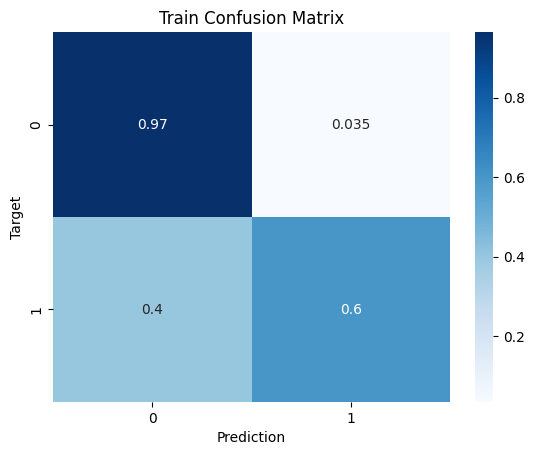

TN FP
FN TP

Area under ROC score on Validation dataset: 0.91%
Accuracy score on Validation dataset: 0.89%


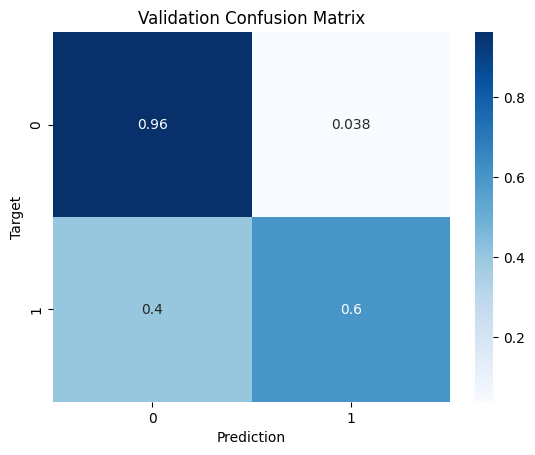

TN FP
FN TP



In [13]:
from sklearn.preprocessing import PolynomialFeatures

numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

preprocessor_polynomial = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat_onehot', OneHotEncoder(handle_unknown="ignore"), cat_onehot_cols),
        ('cat_label', OrdinalEncoder(), cat_ordinal_cols)
    ])

model_pipeline_plus_pf2 = Pipeline(steps=[
    ('preprocessor', preprocessor_polynomial),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline_plus_pf2.fit(train_inputs, train_targets)

train_preds = predict_and_plot(model_pipeline_plus_pf2, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_plus_pf2, val_inputs, val_targets, 'Validation')

Результати покращились. Ні overfit ні underfit не спостерігається, оскільки 1 - оцінки близькі на тренувальних та тестувальних даних, 2 - оцінка якості досить висока. Вважаю, генералізує модель добре, в нас трохи виросли показники true pos&neg в confusion matrix і в цілому є досить високими

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train dataset: 0.93%
Accuracy score on Train dataset: 0.90%


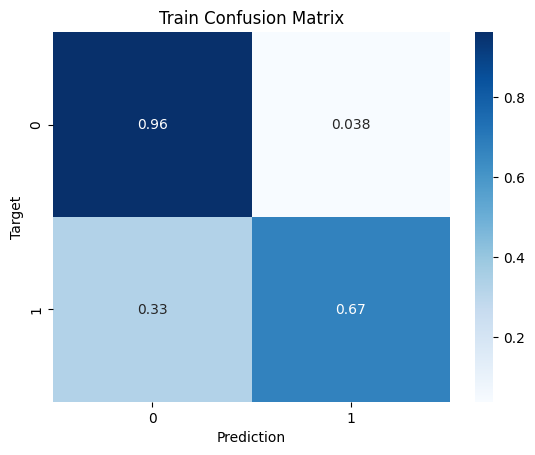

TN FP
FN TP

Area under ROC score on Validation dataset: 0.92%
Accuracy score on Validation dataset: 0.89%


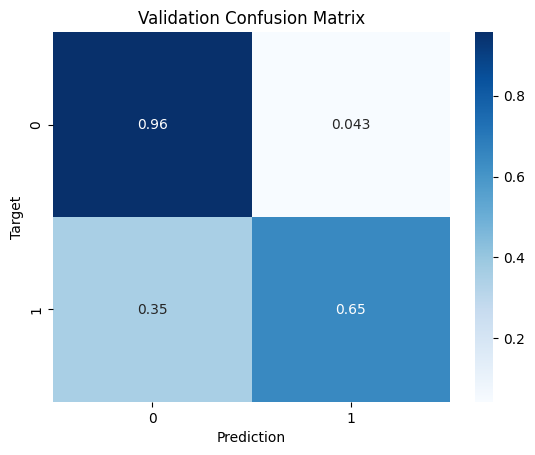

TN FP
FN TP



In [19]:
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=4, include_bias=False))
])

preprocessor_polynomial = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat_onehot', OneHotEncoder(handle_unknown="ignore"), cat_onehot_cols),
        ('cat_label', OrdinalEncoder(), cat_ordinal_cols)
    ])

model_pipeline_plus_pf4 = Pipeline(steps=[
    ('preprocessor', preprocessor_polynomial),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline_plus_pf4.fit(train_inputs, train_targets)

train_preds = predict_and_plot(model_pipeline_plus_pf4, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_plus_pf4, val_inputs, val_targets, 'Validation')

Стало ще трохи краще - оцінки якості ще виросли

In [20]:
test_raw_df = pd.read_csv('test.csv')
test_raw_df['Exited'] =  model_pipeline_plus_pf4.predict(test_raw_df)

submission_raw_df = pd.read_csv('sample_submission.csv')
submission_raw_df['Exited'] = test_raw_df.Exited
submission_raw_df.to_csv("submission_log_reg_pl4.csv", index=False)

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

reg_raw_df = pd.read_csv('regression_data.csv')

train_df, test_df = train_test_split(reg_raw_df, test_size = 0.2, random_state=42)

input_cols = list(reg_raw_df.columns)[1:-1]
target_col = 'target'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
test_inputs, test_targets = test_df[input_cols].copy(), test_df[target_col].copy()

transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=5, include_bias=False))
])

preprocessor_linear = ColumnTransformer(
    transformers=[
        ('transformer', transformer, input_cols),
    ])

model_linear = Pipeline(steps=[
    ('preprocessor', preprocessor_linear),
    ('classifier', LinearRegression())
])

model_linear.fit(train_inputs, train_targets)

train_preds = model_linear.predict(train_inputs)
test_preds = model_linear.predict(test_inputs)

print(f"TRAIIN\nR2 score :{ r2_score(train_targets, train_preds):.2f}")
print(f"RMSE score : {root_mean_squared_error(train_targets, train_preds):.2f}")
print(f"TEST\nR2 score : {r2_score(test_targets, test_preds):.2f}")
print(f"RMSE score : {root_mean_squared_error(test_targets, test_preds):.2f}")

TRAIIN
R2 score :1.00
RMSE score : 0.00
TEST
R2 score : -2.49
RMSE score : 90.20


В даному випадку спостерігається ovefitting моделі - ідеальні значення тренувадбного датасету та погані значення тестового - модель зазубрила наявні дані і погано генералізує

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [53]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

models = [
    Ridge(),
    Lasso(alpha=0.5, max_iter=700),
    ElasticNet(alpha=0.5)
]

def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    test_rmse = root_mean_squared_error(y_test, y_test_pred)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(model.n_iter_)

    return dict(train_rmse=train_rmse, test_rmse=test_rmse, train_r2=train_r2, test_r2=test_r2)

train_inputs.shape

(103, 4)

In [32]:
poly_features = PolynomialFeatures(degree=20)
X_train_poly = poly_features.fit_transform(train_inputs)
X_test_poly = poly_features.transform(test_inputs)
X_train_poly.shape

(103, 10626)

In [54]:
for model in models:
    model.fit(X_train_poly, train_targets)
    eval_results  = evaluate_model(model, X_train_poly, train_targets, X_test_poly, test_targets)
    print(f'{str(model)}: {eval_results:}\n')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


None
Ridge(alpha=2): {'train_rmse': 28.4330400634758, 'test_rmse': 8234.44241254583, 'train_r2': 0.5849545263675643, 'test_r2': -29062.068232095804}



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.557e+03, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(


700
Lasso(alpha=0.5, max_iter=700): {'train_rmse': 1.3360309852498358, 'test_rmse': 4.621004774000539, 'train_r2': 0.9990836061861499, 'test_r2': 0.9908473700750466}

1000
ElasticNet(alpha=0.5): {'train_rmse': 8.583940204573318, 'test_rmse': 300.9903251629745, 'train_r2': 0.9621712095412546, 'test_r2': -37.83096115512103}



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.120e+03, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(


In [56]:
reg_raw_df.corr()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
feature_1,1.000000,0.090286,0.068160,0.005709,0.112917,0.007453
feature_2,0.090286,1.000000,-0.031918,-0.050098,0.075303,-0.049995
feature_3,0.068160,-0.031918,1.000000,-0.043707,0.016758,-0.042851
feature_4,0.005709,-0.050098,-0.043707,1.000000,-0.151899,0.999734
feature_5,0.112917,0.075303,0.016758,-0.151899,1.000000,-0.155143
target,0.007453,-0.049995,-0.042851,0.999734,-0.155143,1.000000


In [20]:
reg_raw_df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
count,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000
mean,-0.082039,-0.017872,0.092293,-0.076084,0.053098,-3.902984
std,0.941214,1.065887,0.978557,0.910588,1.004498,45.466621
min,-3.241267,-2.619745,-1.913280,-2.211135,-2.301921,-111.753810
25%,-0.699726,-0.756351,-0.553649,-0.730367,-0.772825,-37.339533
50%,-0.066080,-0.161286,0.120296,0.018418,0.013002,-0.641298
75%,0.529804,0.679598,0.624120,0.519347,0.787085,25.464414
max,2.122156,3.852731,3.078881,2.314659,2.075401,115.125907


Lasso регуляризайція спрацювала у данному випадку найкраще і значно покращила модель. Саме вона спрацювала добре, бо ми маємо великий дизбаланс у співвідношенні кількості рядків та стовців, оскільки нагенерували поліноміальних ознак у 20 ступені, але більшість із цих фічей не є значущими, тож Lasso регуляризація просто викинула їх із моделі(зробила коефіцієнт =0) і залишила найбільш підходящі.

Я ще трохи зменшила кількість ітерацій та підкрутила alpha, і метрики r-квадрат та rmse стали ще кращими.